# 1.Import Libraries

In [ ]:
import torch


print(torch.__version__)
print(torch.cuda.is_available())

In [5]:
import torch
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm

RuntimeError: generic_type: cannot initialize type "RpcBackendOptions": an object with that name is already defined

# 2.Device

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 3.Transforms

In [38]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.02
    ),

    transforms.RandomGrayscale(p=0.1),

    transforms.GaussianBlur(kernel_size=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# 4.Dataset paths

In [39]:
train_dir = "/mnt/d/deepfake/tf-gpu-env/complete_project/faces_train_test/train"
val_dir = "/mnt/d/deepfake/tf-gpu-env/complete_project/faces_train_test/val"

# 5.Load Datasets

In [40]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
val_dataset = datasets.ImageFolder(val_dir, transform=transform_val)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

Train images: 39619
Val images: 9906


# 6. DataModel

In [41]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# 6.Load Model

In [42]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=2
)

# Freeze backbone
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = True

model = model.to(device)

# 7.Loss and Optimizer

In [43]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-5
)

# 8.Training Function

In [44]:
def train_epoch():

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images,labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _,preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()
        total += labels.size(0)

        loop.set_description("Training")
        loop.set_postfix(loss=loss.item())

    acc = correct/total

    return running_loss,acc

# 9.Validation Function

In [45]:
def validate():

    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():

        loop = tqdm(val_loader)

        for images,labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs,labels)

            val_loss += loss.item()

            _,preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()
            total += labels.size(0)

            loop.set_description("Validation")

    acc = correct/total

    return val_loss,acc

# 10.Training Loop

In [25]:
epochs = 8

best_acc = 0.8124

for epoch in range(epochs):

    print("\nEpoch:", epoch+1)

    train_loss,train_acc = train_epoch()

    val_loss,val_acc = validate()

    print("Train Acc:",train_acc)
    print("Val Acc:",val_acc)

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/mnt/d/deepfake/tf-gpu-env/complete_project/models/efficientnet_faces_fina2.pth"
        )

        print("Model Saved")


Epoch: 1


Validation: 100%|█████████████████████████████████████████████████████████████████████| 310/310 [00:38<00:00,  8.11it/s]


Train Acc: 0.7873495040258461
Val Acc: 0.8110236220472441

Epoch: 2


Validation: 100%|█████████████████████████████████████████████████████████████████████| 310/310 [00:37<00:00,  8.16it/s]


Train Acc: 0.7886620056033721
Val Acc: 0.8077932566121543

Epoch: 3


...

Train Acc: 0.7872737827809889
Val Acc: 0.8094084393296992

Epoch: 4


Validation: 100%|█████████████████████████████████████████████████████████████████████| 310/310 [00:38<00:00,  8.04it/s]


Train Acc: 0.7868446957267977
Val Acc: 0.8089036947304664

Epoch: 5


Training:   3%|█▉                                                         | 41/1239 [00:09<04:40,  4.27it/s, loss=0.655]


KeyboardInterrupt: 

# 11.Load Trained Model

In [46]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(
    torch.load(
        "/mnt/d/deepfake/tf-gpu-env/complete_project/models/efficientnet_faces_fina2.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("EfficientNet model loaded successfully")

EfficientNet model loaded successfully


# 12. Evaluate Model(Metrics)

In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Fake","Real"]))

Confusion Matrix:
[[3293  967]
 [ 860 4786]]

Classification Report:
              precision    recall  f1-score   support

        Fake       0.79      0.77      0.78      4260
        Real       0.83      0.85      0.84      5646

    accuracy                           0.82      9906
   macro avg       0.81      0.81      0.81      9906
weighted avg       0.82      0.82      0.82      9906



# 13.Confusion Matrix

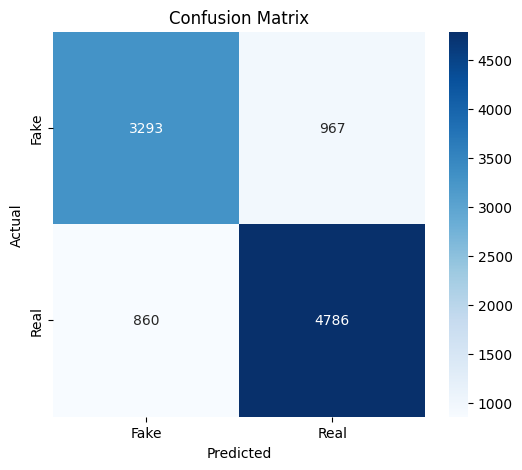

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# 14.Predict Frames

In [49]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [50]:
from PIL import Image
import torchvision.transforms as transforms

def predict_image(image_path):

    img = Image.open(image_path).convert("RGB")

    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        prob = torch.softmax(output, dim=1)

    fake_prob = prob[0][0].item()
    real_prob = prob[0][1].item()

    if fake_prob > real_prob:
        pred = "Fake"
    else:
        pred = "Real"

    print("Prediction:", pred)
    print("Fake probability:", round(fake_prob,3))
    print("Real probability:", round(real_prob,3))

In [57]:
predict_image("/mnt/d/deepfake/tf-gpu-env/complete_project/faces_train_test/val/fake/01_11__secret_conversation__4OJNJLOO_108_0.jpg")

Prediction: Fake
Fake probability: 0.663
Real probability: 0.337


# 15.Predict Video

In [52]:
import cv2

def predict_video(video_path):

    cap = cv2.VideoCapture(video_path)

    fake_scores = []
    real_scores = []

    frame_count = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % 10 == 0:   # sample frames

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(frame)

            img = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(img)
                prob = torch.softmax(output, dim=1)

            fake_scores.append(prob[0][0].item())
            real_scores.append(prob[0][1].item())

        frame_count += 1

    cap.release()

    fake_avg = np.mean(fake_scores)
    real_avg = np.mean(real_scores)

    if fake_avg > real_avg:
        prediction = "Fake"
    else:
        prediction = "Real"

    print("Video Prediction:", prediction)
    print("Fake Score:", round(fake_avg,3))
    print("Real Score:", round(real_avg,3))

In [53]:
predict_video("/mnt/d/deepfake/deepfake-env/FF++/real/01__walking_and_outside_surprised.mp4")

Video Prediction: Fake
Fake Score: 0.939
Real Score: 0.061


In [1]:
from sklearn.metrics import classification_report, accuracy_score
import torch
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Fake","Real"]
    )
)

KeyboardInterrupt: 